In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [124]:
#load the dataset

df = pd.read_csv("dataset/bank-additional-full.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [125]:
# Basic exploration

df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188,41188,41188,41188,41188,41188,41188,41188,41188,...,41188.000000,41188.000000,41188.000000,41188,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188
unique,NaN,12,4,8,3,3,3,2,10,5,...,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,2
top,NaN,admin.,married,university.degree,no,yes,no,cellular,may,thu,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,no
freq,NaN,10422,24928,12168,32588,21576,33950,26144,13769,8623,...,NaN,NaN,NaN,35563,NaN,NaN,NaN,NaN,NaN,36548
mean,40.02406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.567593,962.475454,0.172963,NaN,0.081886,93.575664,-40.502600,3.621291,5167.035911,NaN
std,10.42125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.770014,186.910907,0.494901,NaN,1.570960,0.578840,4.628198,1.734447,72.251528,NaN
min,17.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,NaN
25%,32.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,NaN
50%,38.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,999.000000,0.000000,NaN,1.100000,93.749000,-41.800000,4.857000,5191.000000,NaN
75%,47.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,NaN


In [126]:
# Check for unknown values in the features

(df == "unknown").sum()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [127]:
# Handle unknown values (Flag + Replacement)

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    if "unknown" in df[col].values:
        df[col+"_unknown_flag"] = (df[col]=="unknown").astype(int)
        mode_val = df[col].replace("unknown", np.nan).mode()[0]
        df[col] = df[col].replace("unknown", mode_val)

In [128]:
df.job_unknown_flag.value_counts()

job_unknown_flag
0    40858
1      330
Name: count, dtype: int64

In [129]:
# Encode categorical variables

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [130]:
df.marital.value_counts()

marital
1    25008
2    11568
0     4612
Name: count, dtype: int64

In [131]:
# Split Features and Target

X = df.drop("y", axis=1)
y = df["y"]

In [132]:
# Identify Low-Variance features

low_variance_cols = [col for col in X.columns if X[col].nunique() <= 1]
low_variance_cols

[]

In [133]:
# Remove Low-Variance features
X.drop(columns=low_variance_cols, inplace=True)

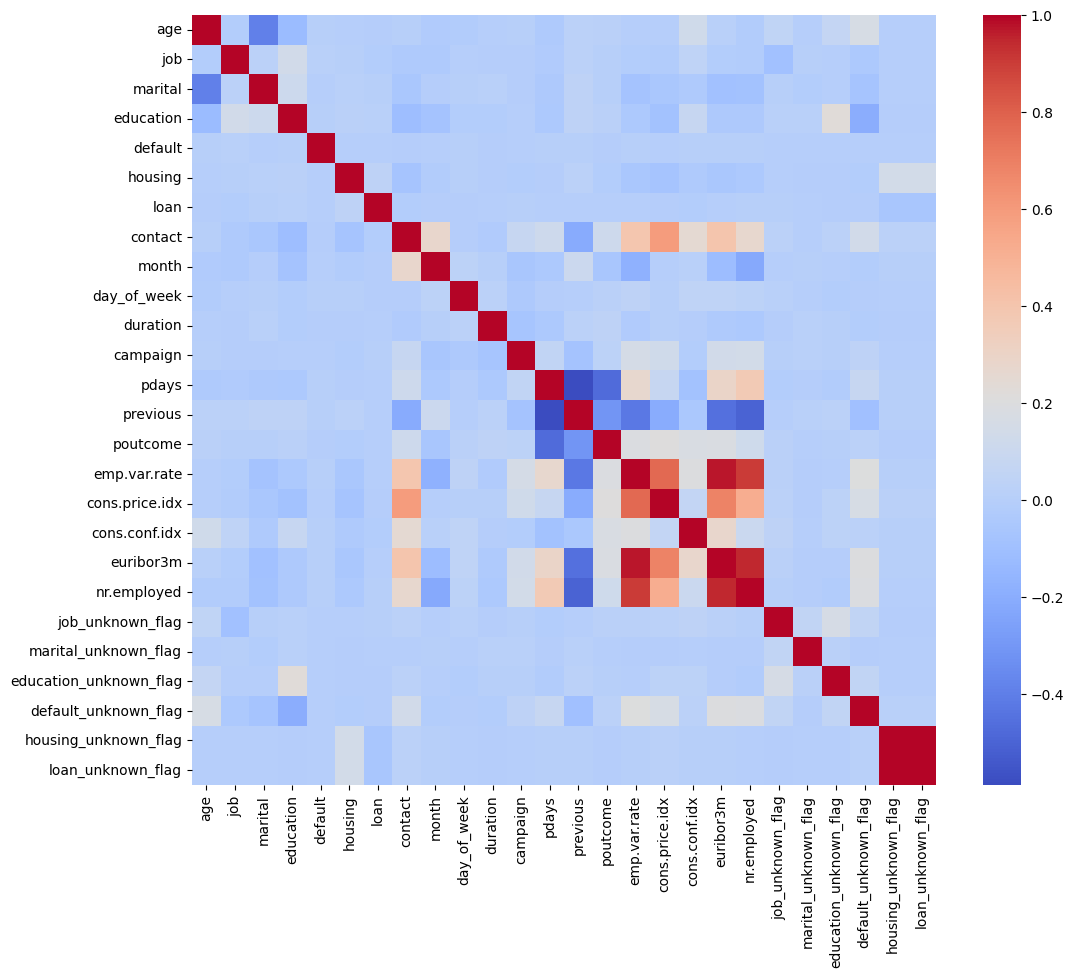

In [134]:
# Correlation Analysis

plt.figure(figsize=(12,10))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.show()

In [135]:
# Identify highly correlated features (>0.85)

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_cols = [column for column in upper.columns if any(upper[column] > 0.85)]
drop_cols

['euribor3m', 'nr.employed', 'loan_unknown_flag']

In [136]:
# Remove highly correlated features (>0.85)

X.drop(columns=drop_cols, inplace=True)

In [137]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     41188 non-null  int64  
 1   job                     41188 non-null  int64  
 2   marital                 41188 non-null  int64  
 3   education               41188 non-null  int64  
 4   default                 41188 non-null  int64  
 5   housing                 41188 non-null  int64  
 6   loan                    41188 non-null  int64  
 7   contact                 41188 non-null  int64  
 8   month                   41188 non-null  int64  
 9   day_of_week             41188 non-null  int64  
 10  duration                41188 non-null  int64  
 11  campaign                41188 non-null  int64  
 12  pdays                   41188 non-null  int64  
 13  previous                41188 non-null  int64  
 14  poutcome                41188 non-null

In [138]:
X.head(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,job_unknown_flag,marital_unknown_flag,education_unknown_flag,default_unknown_flag,housing_unknown_flag
0,56,3,1,0,0,0,0,1,6,1,...,0,1,1.1,93.994,-36.4,0,0,0,0,0
1,57,7,1,3,0,0,0,1,6,1,...,0,1,1.1,93.994,-36.4,0,0,0,1,0
2,37,7,1,3,0,1,0,1,6,1,...,0,1,1.1,93.994,-36.4,0,0,0,0,0
3,40,0,1,1,0,0,0,1,6,1,...,0,1,1.1,93.994,-36.4,0,0,0,0,0
4,56,7,1,3,0,0,1,1,6,1,...,0,1,1.1,93.994,-36.4,0,0,0,0,0


In [ ]:
# from sklearn.preprocessing import MinMaxScaler
# X_scaled = MinMaxScaler().fit_transform(X)
# chi2(X_scaled, y)

(array([2.21638815e+00, 9.26651650e+00, 1.34928343e+01, 2.63181362e+01,
        3.80868994e-01, 2.28828497e+00, 6.96920402e-01, 5.47958309e+02,
        2.14142671e-01, 2.55786114e+00, 3.58018123e+02, 1.61401287e+01,
        1.57983753e+02, 4.41453204e+02, 4.91155872e+01, 5.41304067e+02,
        7.25854703e+01, 1.07957848e+01, 9.37694452e-04, 1.11617940e+00,
        1.81205348e+01, 3.21320431e+02, 2.07141139e-01]),
 array([1.36552188e-001, 2.33381158e-003, 2.39476195e-004, 2.89556778e-007,
        5.37138532e-001, 1.30353891e-001, 4.03820422e-001, 3.50059831e-121,
        6.43539618e-001, 1.09746971e-001, 7.60563103e-080, 5.88243500e-005,
        3.12026131e-036, 5.22605834e-098, 2.41314989e-012, 9.81151348e-120,
        1.59952375e-017, 1.01731477e-003, 9.75571159e-001, 2.90742617e-001,
        2.07353177e-005, 7.46938234e-072, 6.49017437e-001]))

In [ ]:
# Statistical feature selection (Chi Square)

chi_scores = chi2(X_scaled, y)
chi_df = pd.DataFrame({
    "Feature": X_scaled.columns,
    "Score": chi_scores[0],
    "p-value": chi_scores[1]
}).sort_values(by="Score", ascending=False)

chi_df.head(10)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [140]:
# # Statistical feature selection (Chi square)

# import pandas as pd
# import numpy as np

# from sklearn.preprocessing import MinMaxScaler
# from sklearn.feature_selection import chi2, f_classif, mutual_info_classif

# # -------------------------
# # 1. Scale for Chi-square
# # -------------------------
# scaler = MinMaxScaler()
# X_scaled = scaler.fit_transform(X)

# # -------------------------
# # 2. Compute Scores
# # -------------------------
# chi_scores, chi_p = chi2(X_scaled, y)
# anova_scores, anova_p = f_classif(X, y)
# mi_scores = mutual_info_classif(X, y, random_state=42)

# # -------------------------
# # 3. Combine Results
# # -------------------------
# feature_scores = pd.DataFrame({
#     "Feature": X.columns,
#     "Chi2 Score": chi_scores,
#     "Chi2 p-value": chi_p,
#     "ANOVA Score": anova_scores,
#     "ANOVA p-value": anova_p,
#     "Mutual Info": mi_scores
# })

# # -------------------------
# # 4. Rank Features
# # -------------------------
# feature_scores["Chi2 Rank"] = feature_scores["Chi2 Score"].rank(ascending=False)
# feature_scores["ANOVA Rank"] = feature_scores["ANOVA Score"].rank(ascending=False)
# feature_scores["MI Rank"] = feature_scores["Mutual Info"].rank(ascending=False)

# feature_scores["Average Rank"] = feature_scores[
#     ["Chi2 Rank","ANOVA Rank","MI Rank"]
# ].mean(axis=1)

# feature_scores = feature_scores.sort_values("Average Rank")

# # -------------------------
# # 5. Show Top Features
# # -------------------------
# feature_scores.head(15)

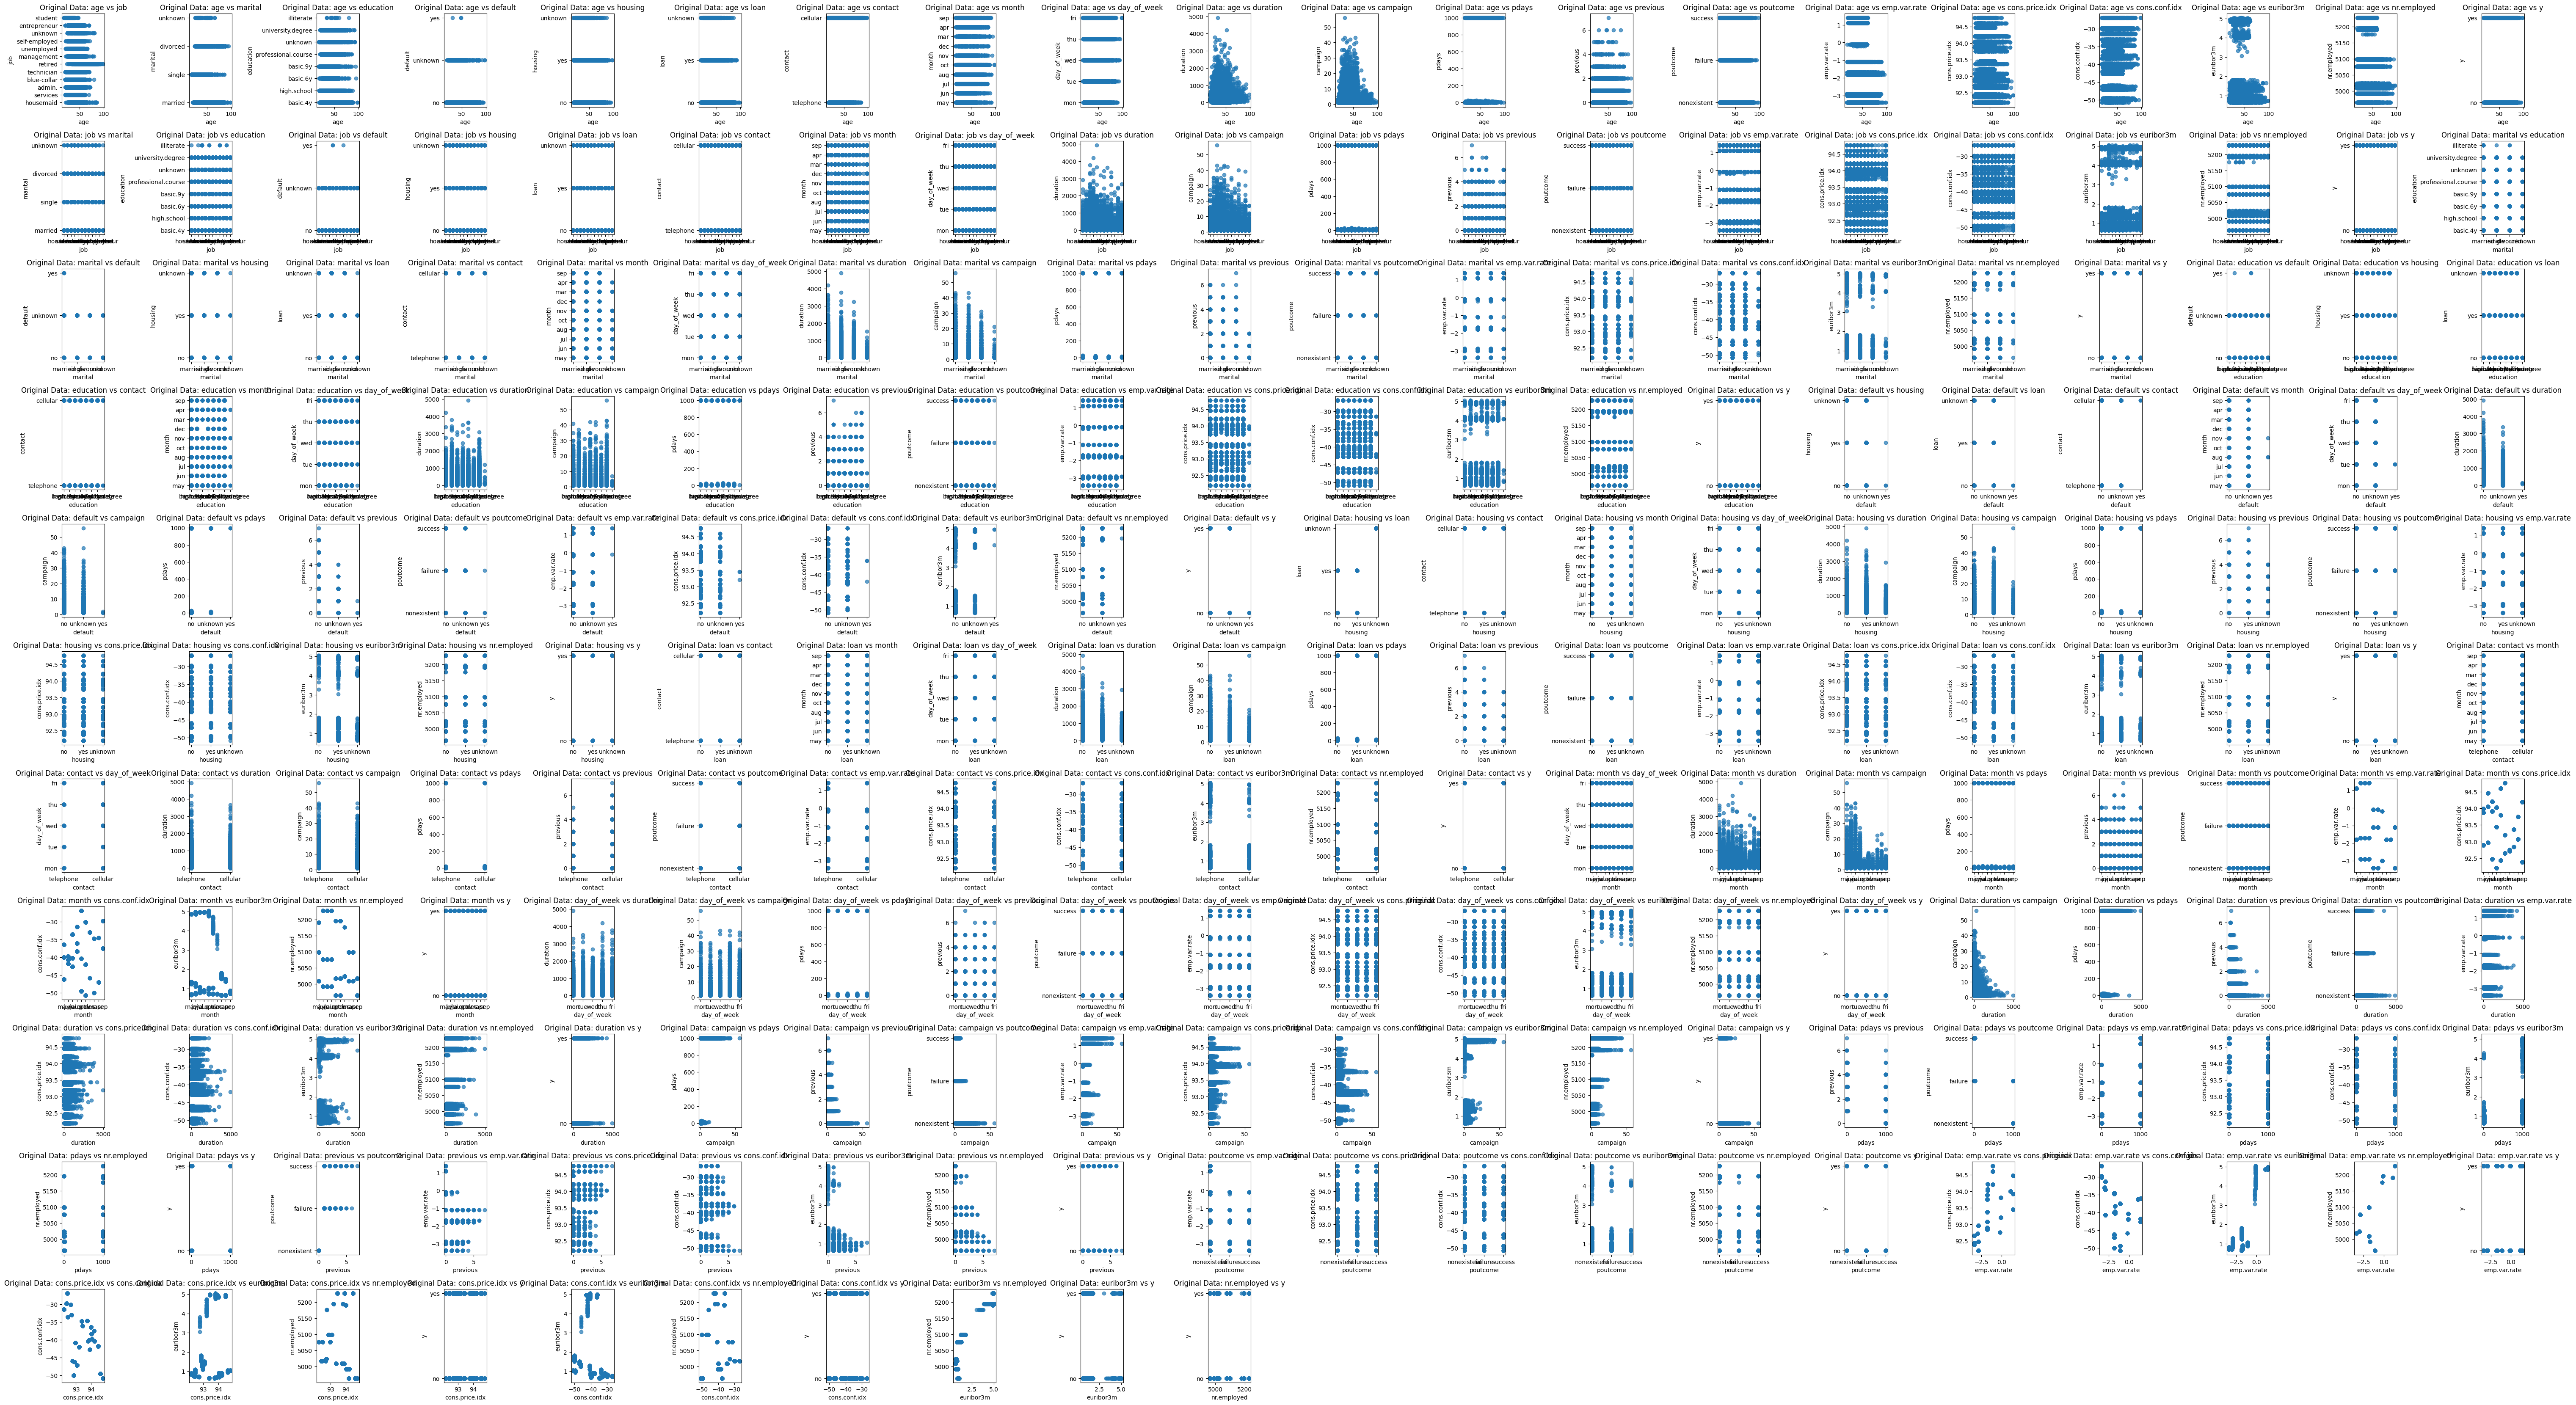

In [141]:
def plot_feature_pairs(data, feature_names, color_labels=None, title_prefix=''):
    """
    Helper function to create scatter plots for all possible pairs of features.
    
    Parameters:
    - data: DataFrame containing the features to be plotted.
    - feature_names: List of feature names to be used in plotting.
    - color_labels: Optional. Cluster or class labels to color the scatter plots.
    - title_prefix: Optional. Prefix for plot titles to distinguish between different sets of plots.
    """
    # Create a figure for the scatter plots
    plt.figure(figsize=(60, 60))
    
    # Counter for subplot index
    plot_number = 1
    
    # Loop through each pair of features
    for i in range(len(feature_names)):
        for j in range(i + 1, len(feature_names)):
            plt.subplot(len(feature_names)-1, len(feature_names)-1, plot_number)
            
            # Scatter plot colored by labels if provided
            if color_labels is not None:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], 
                            c=color_labels, cmap='viridis', alpha=0.7)
            else:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], alpha=0.7)
            
            plt.xlabel(feature_names[i])
            plt.ylabel(feature_names[j])
            plt.title(f'{title_prefix}{feature_names[i]} vs {feature_names[j]}')
            
            # Increment the plot number
            plot_number += 1

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the plot
    plt.show()

# Get feature names
feature_names = bm_df.columns

# Use the helper function to plot scatter plots without coloring by cluster labels
plot_feature_pairs(bm_df, feature_names, title_prefix='Original Data: ')

In [142]:
u_cols = ["job","marital","education","housing","loan"]

In [143]:
bm.loc[bm["marital"] == 'unknown', "age"].min()

np.int64(25)

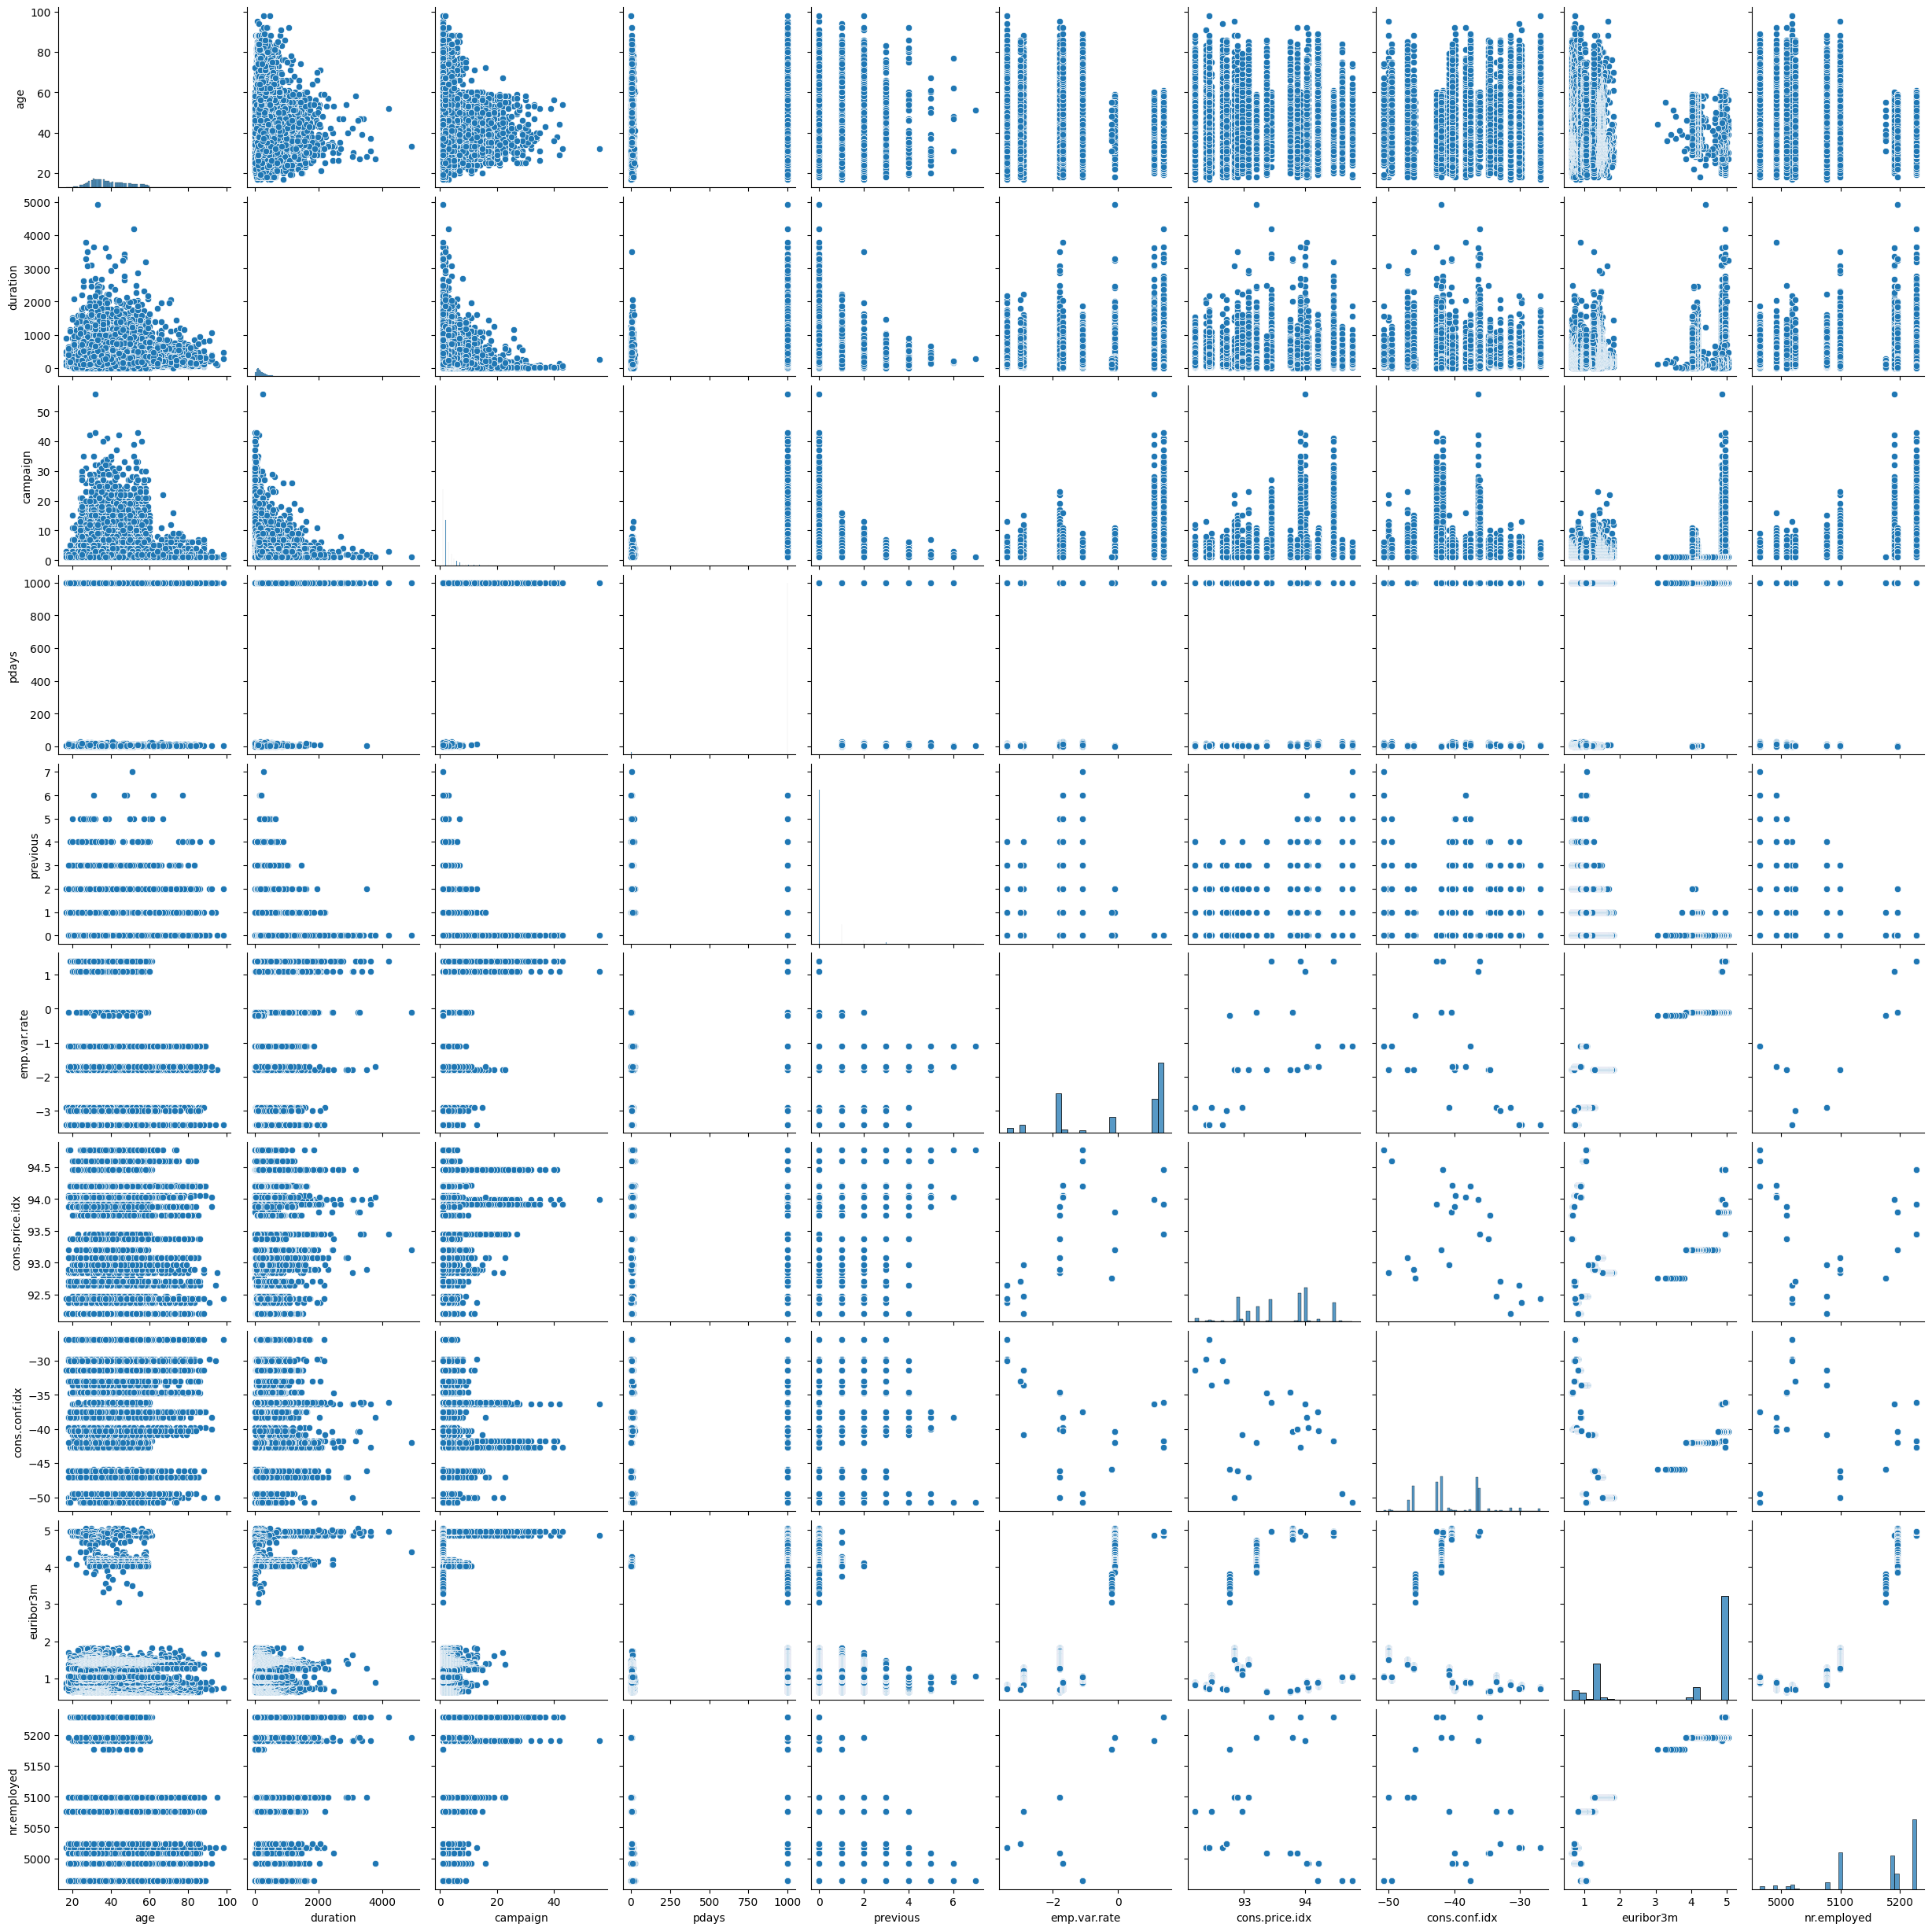

In [144]:
import seaborn as sns

#bank_marketing.corr(numeric_only=True)
sns.pairplot(bm)


In [145]:
# 

import pandas as pd

cols = ["job","education","housing"]

for col in cols:
    # flag column
    df[f"{col}_unknown"] = (df[col] == "unknown").astype(int)
    
    # replace unknown with mode
    mode_val = df[col].replace("unknown", pd.NA).mode()[0]
    df[col] = df[col].replace("unknown", mode_val)

print(df)

       age  job  marital  education  default  housing  loan  contact  month  \
0       56    3        1          0        0        0     0        1      6   
1       57    7        1          3        0        0     0        1      6   
2       37    7        1          3        0        1     0        1      6   
3       40    0        1          1        0        0     0        1      6   
4       56    7        1          3        0        0     1        1      6   
...    ...  ...      ...        ...      ...      ...   ...      ...    ...   
41183   73    5        1          5        0        1     0        0      7   
41184   46    1        1          5        0        0     0        0      7   
41185   56    5        1          6        0        1     0        0      7   
41186   44    9        1          5        0        0     0        0      7   
41187   74    5        1          5        0        1     0        0      7   

       day_of_week  ...  y  job_unknown_flag  marit

In [146]:
bm.head(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [147]:
bm.poutcome.value_counts(normalize=True)

poutcome
nonexistent    0.863431
failure        0.103234
success        0.033335
Name: proportion, dtype: float64

In [148]:
# Label Encoding of categorical columns
cat_cols = bm_df.select_dtypes(include="object").columns

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in cat_cols:
    bm_df[col] = le.fit_transform(bm_df[col])